In [2]:
import csv
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
#from sklearn.preprocessing import Normalizer
#from sklearn.preprocessing import StandardScaler
import joblib
df = pd.read_csv("laptop_prices.csv")
df.columns = df.columns.str.replace(" ","_")
df.Processor = df.Processor.str.replace(" ","_")
df.GPU = df.GPU.str.replace(" ","_")
#df.GPU = df.GPU.str.replace(" ","_")
print(df)
#df["Storage"]
#["Storage"]
print(df.Storage)
df.isnull().sum()
type(df.Storage)
col_name=df.columns
col_name

         Brand    Processor  RAM_(GB)    Storage                 GPU  \
0        Apple  AMD_Ryzen_3        64  512GB SSD     Nvidia_GTX_1650   
1        Razer  AMD_Ryzen_7         4    1TB SSD     Nvidia_RTX_3080   
2         Asus     Intel_i5        32    2TB SSD     Nvidia_RTX_3060   
3       Lenovo     Intel_i5         4  256GB SSD     Nvidia_RTX_3080   
4        Razer     Intel_i3         4  256GB SSD  AMD_Radeon_RX_6600   
...        ...          ...       ...        ...                 ...   
11763     Acer     Intel_i3         4    2TB SSD     Nvidia_RTX_2060   
11764     Asus     Intel_i3         4    2TB SSD  AMD_Radeon_RX_6800   
11765    Razer  AMD_Ryzen_9         4    2TB SSD  AMD_Radeon_RX_6600   
11766  Samsung  AMD_Ryzen_7        16  512GB SSD          Integrated   
11767  Samsung     Intel_i7         8  256GB SSD     Nvidia_RTX_3080   

       Screen_Size_(inch) Resolution  Battery_Life_(hours)  Weight_(kg)  \
0                    17.3  2560x1440                   8.9  

Index(['Brand', 'Processor', 'RAM_(GB)', 'Storage', 'GPU',
       'Screen_Size_(inch)', 'Resolution', 'Battery_Life_(hours)',
       'Weight_(kg)', 'Operating_System', 'Price_($)'],
      dtype='object')

In [3]:
df.Storage.value_counts()

Storage
512GB SSD    2420
2TB SSD      2415
256GB SSD    2318
1TB SSD      2313
1TB HDD      2302
Name: count, dtype: int64

df["Storage_in_SSD"]=[]
df["Storage_in_HDD"]=[]
for i in range(len(df.Storage)):
    if df.Storage[i][-1:-3] == "SSD" and i[-6] == "G":
        df["Storage_in_SSD"][i]=int(df.Storage[i][:-6])
        df["Storage_in_HDD"][i]=0
    if df.Storage[i][-1:-3] == "SSD" and i[-6] == "T":
        df["Storage_in_SSD"][i]=int(df.Storage[i][:-6])*1024
        df["Storage_in_HDD"][i]=0
    if df.Storage[i][-1:-3] == "HDD" and i[-6] == "G":
        df["Storage_in_HDD"][i]=int(df.Storage[i][:-6])
        df["Storage_in_SSD"][i]=0
    if df.Storage[i][-1:-3] == "HDD" and i[-6] == "T":
        df["Storage_in_HDD"][i]=int(df.Storage[i][:-6])*1024
        df["Storage_in_SSD"][i]=0
        
df.Storage_in_SSD

In [4]:
#creatinh seperate table for ssd and hdd
#df["Storage_in_HDD"]=df["Storage"]
df["Storage_in_HDD"]=df.Storage.where(~df.Storage.str.endswith("SSD"), "0")
df["Storage_in_SSD"]=df.Storage.where(~df.Storage.str.endswith("HDD"), "0")
print(df.Storage_in_HDD.value_counts())
print(df.Storage_in_SSD.value_counts())

Storage_in_HDD
0          9466
1TB HDD    2302
Name: count, dtype: int64
Storage_in_SSD
512GB SSD    2420
2TB SSD      2415
256GB SSD    2318
1TB SSD      2313
0            2302
Name: count, dtype: int64


In [5]:
df


,Brand,Processor,RAM_(GB),Storage,GPU,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),Storage_in_HDD,Storage_in_SSD
0,Apple,AMD_Ryzen_3,64,512GB SSD,Nvidia_GTX_1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,0,512GB SSD
1,Razer,AMD_Ryzen_7,4,1TB SSD,Nvidia_RTX_3080,14.0,1366x768,9.4,2.57,Linux,1355.78,0,1TB SSD
2,Asus,Intel_i5,32,2TB SSD,Nvidia_RTX_3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,0,2TB SSD
3,Lenovo,Intel_i5,4,256GB SSD,Nvidia_RTX_3080,13.3,1366x768,10.5,3.10,Windows,751.17,0,256GB SSD
4,Razer,Intel_i3,4,256GB SSD,AMD_Radeon_RX_6600,16.0,3840x2160,5.7,3.38,Linux,2059.83,0,256GB SSD
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,Acer,Intel_i3,4,2TB SSD,Nvidia_RTX_2060,17.3,1366x768,11.5,1.58,macOS,704.82,0,2TB SSD
11764,Asus,Intel_i3,4,2TB SSD,AMD_Radeon_RX_6800,16.0,1366x768,9.5,2.14,Linux,775.59,0,2TB SSD
11765,Razer,AMD_Ryzen_9,4,2TB SSD,AMD_Radeon_RX_6600,15.6,2560x1440,8.2,2.05,Linux,2789.46,0,2TB SSD
11766,Samsung,AMD_Ryzen_7,16,512GB SSD,Integrated,13.3,1920x1080,7.5,1.48,macOS,1067.13,0,512GB SSD


In [6]:
def convert_to_gb(size_str):
    if isinstance(size_str, str): # Check if it is string to avoid error
        match = re.match(r'([\d.]+)([GMT]?B)', size_str)
        if match:
            size = float(match.group(1))

            unit = match.group(2) or 'B'  # Default to 'B' if no unit is specified
            if unit == 'TB':
                size *= 1024
            return size
    return None

df['Storage_hdd_gb'] = df['Storage_in_HDD'].apply(convert_to_gb)
df['Storage_ssd_gb'] = df['Storage_in_SSD'].apply(convert_to_gb)
df = df.fillna({'Storage_hdd_gb': 0, 'Storage_ssd_gb': 0})
print(df.Storage_hdd_gb.value_counts())
print(df.Storage_ssd_gb.value_counts())

Storage_hdd_gb
0.0       9466
1024.0    2302
Name: count, dtype: int64
Storage_ssd_gb
512.0     2420
2048.0    2415
256.0     2318
1024.0    2313
0.0       2302
Name: count, dtype: int64


In [7]:
#Extracting numerical feature height and width from resolution
df[["Resolution_height","Resolution_width"]]=df["Resolution"].str.extract(r'(\d+)x(\d+)').astype(float)
df

,Brand,Processor,RAM_(GB),Storage,GPU,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),Storage_in_HDD,Storage_in_SSD,Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width
0,Apple,AMD_Ryzen_3,64,512GB SSD,Nvidia_GTX_1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,0,512GB SSD,0.0,512.0,2560.0,1440.0
1,Razer,AMD_Ryzen_7,4,1TB SSD,Nvidia_RTX_3080,14.0,1366x768,9.4,2.57,Linux,1355.78,0,1TB SSD,0.0,1024.0,1366.0,768.0
2,Asus,Intel_i5,32,2TB SSD,Nvidia_RTX_3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,0,2TB SSD,0.0,2048.0,3840.0,2160.0
3,Lenovo,Intel_i5,4,256GB SSD,Nvidia_RTX_3080,13.3,1366x768,10.5,3.10,Windows,751.17,0,256GB SSD,0.0,256.0,1366.0,768.0
4,Razer,Intel_i3,4,256GB SSD,AMD_Radeon_RX_6600,16.0,3840x2160,5.7,3.38,Linux,2059.83,0,256GB SSD,0.0,256.0,3840.0,2160.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,Acer,Intel_i3,4,2TB SSD,Nvidia_RTX_2060,17.3,1366x768,11.5,1.58,macOS,704.82,0,2TB SSD,0.0,2048.0,1366.0,768.0
11764,Asus,Intel_i3,4,2TB SSD,AMD_Radeon_RX_6800,16.0,1366x768,9.5,2.14,Linux,775.59,0,2TB SSD,0.0,2048.0,1366.0,768.0
11765,Razer,AMD_Ryzen_9,4,2TB SSD,AMD_Radeon_RX_6600,15.6,2560x1440,8.2,2.05,Linux,2789.46,0,2TB SSD,0.0,2048.0,2560.0,1440.0
11766,Samsung,AMD_Ryzen_7,16,512GB SSD,Integrated,13.3,1920x1080,7.5,1.48,macOS,1067.13,0,512GB SSD,0.0,512.0,1920.0,1080.0


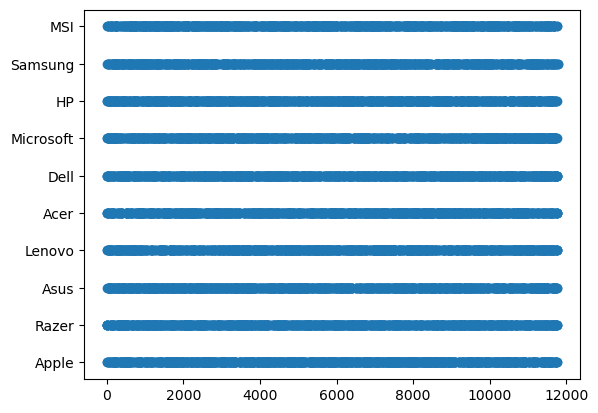

In [8]:
plt.scatter(df.index,df["Brand"])

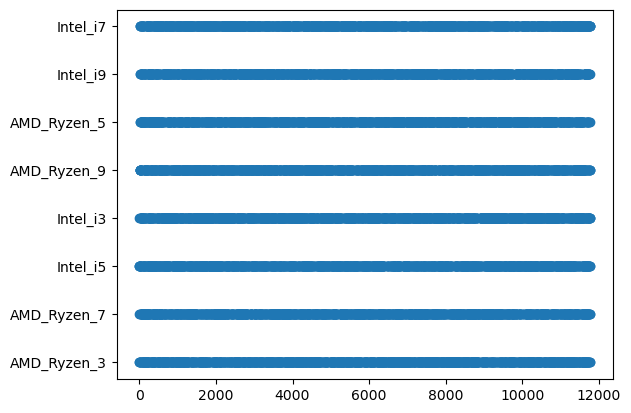

In [9]:
plt.scatter(df.index,df["Processor"])

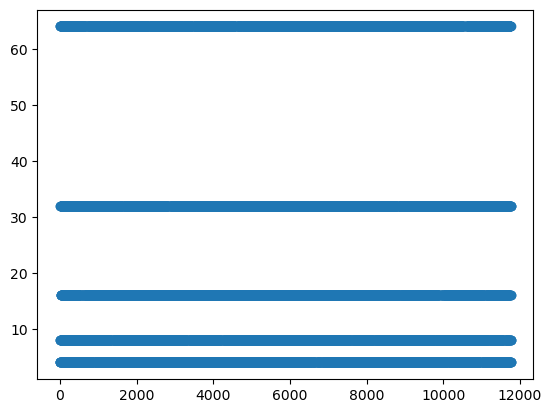

In [10]:
plt.scatter(df.index,df["RAM_(GB)"])

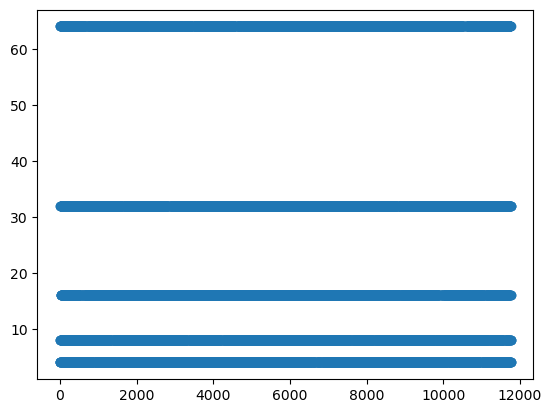

In [11]:
plt.scatter(df.index,df["RAM_(GB)"])

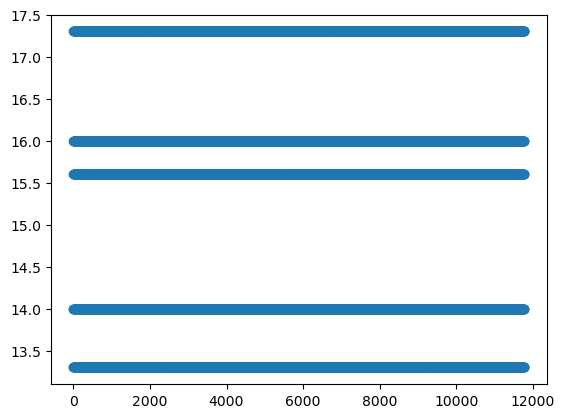

In [12]:
plt.scatter(df.index,df["Screen_Size_(inch)"])

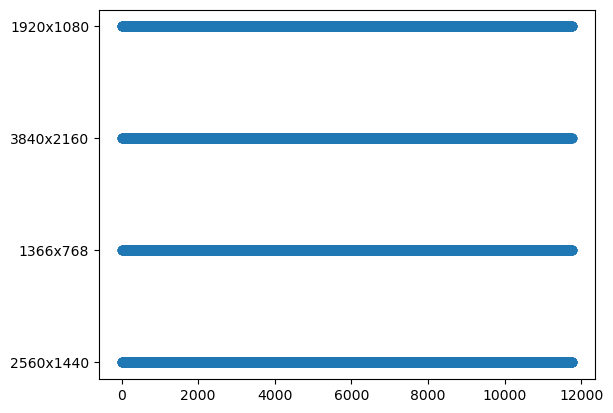

In [13]:
plt.scatter(df.index,df["Resolution"])

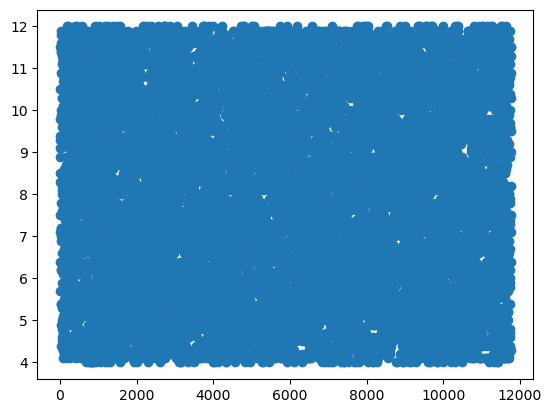

In [14]:
plt.scatter(df.index,df["Battery_Life_(hours)"])

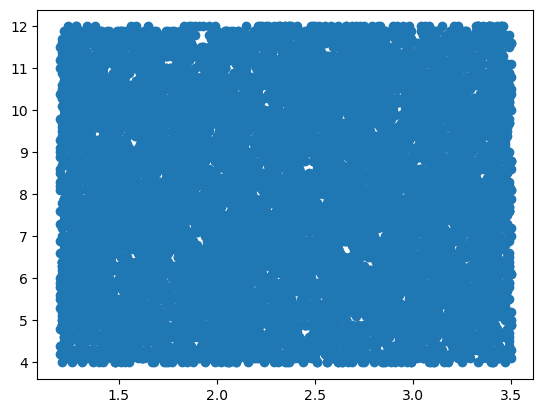

In [15]:
plt.scatter(df["Weight_(kg)"],df["Battery_Life_(hours)"])

In [16]:
correlation_ab = df["Weight_(kg)"].corr(df["Battery_Life_(hours)"])
correlation_ab

-0.0017738733625152969

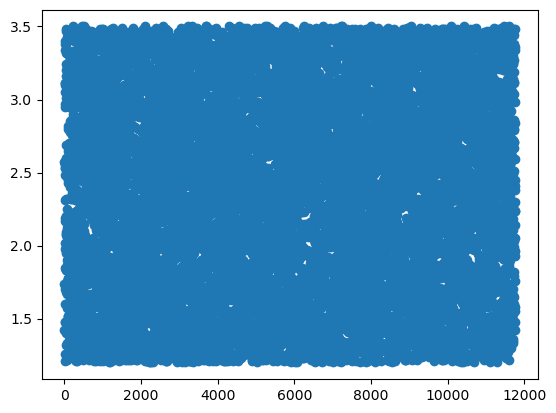

In [17]:
plt.scatter(df.index,df["Weight_(kg)"])

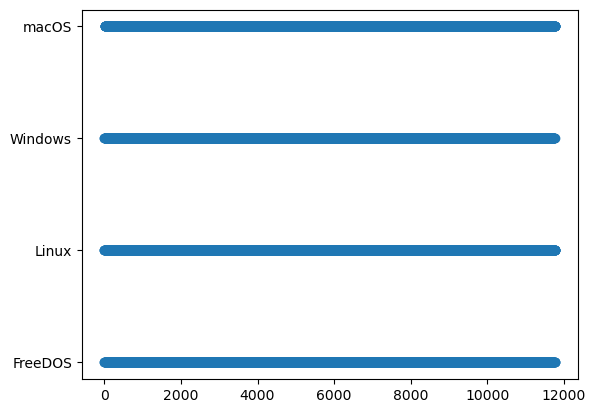

In [18]:

plt.scatter(df.index,df["Operating_System"])

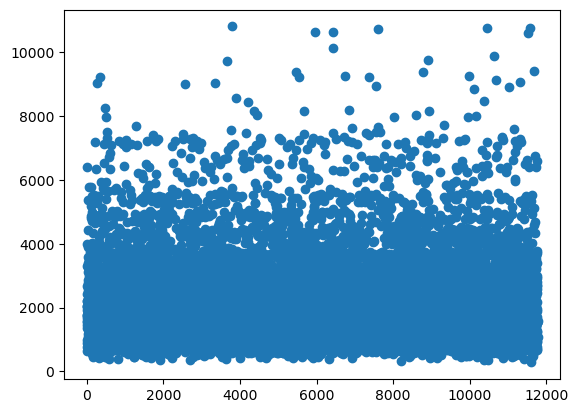

In [19]:
plt.scatter(df.index,df["Price_($)"])

In [20]:
type(df["Resolution"][0])

str

In [21]:
df


,Brand,Processor,RAM_(GB),Storage,GPU,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),Storage_in_HDD,Storage_in_SSD,Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width
0,Apple,AMD_Ryzen_3,64,512GB SSD,Nvidia_GTX_1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,0,512GB SSD,0.0,512.0,2560.0,1440.0
1,Razer,AMD_Ryzen_7,4,1TB SSD,Nvidia_RTX_3080,14.0,1366x768,9.4,2.57,Linux,1355.78,0,1TB SSD,0.0,1024.0,1366.0,768.0
2,Asus,Intel_i5,32,2TB SSD,Nvidia_RTX_3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,0,2TB SSD,0.0,2048.0,3840.0,2160.0
3,Lenovo,Intel_i5,4,256GB SSD,Nvidia_RTX_3080,13.3,1366x768,10.5,3.10,Windows,751.17,0,256GB SSD,0.0,256.0,1366.0,768.0
4,Razer,Intel_i3,4,256GB SSD,AMD_Radeon_RX_6600,16.0,3840x2160,5.7,3.38,Linux,2059.83,0,256GB SSD,0.0,256.0,3840.0,2160.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,Acer,Intel_i3,4,2TB SSD,Nvidia_RTX_2060,17.3,1366x768,11.5,1.58,macOS,704.82,0,2TB SSD,0.0,2048.0,1366.0,768.0
11764,Asus,Intel_i3,4,2TB SSD,AMD_Radeon_RX_6800,16.0,1366x768,9.5,2.14,Linux,775.59,0,2TB SSD,0.0,2048.0,1366.0,768.0
11765,Razer,AMD_Ryzen_9,4,2TB SSD,AMD_Radeon_RX_6600,15.6,2560x1440,8.2,2.05,Linux,2789.46,0,2TB SSD,0.0,2048.0,2560.0,1440.0
11766,Samsung,AMD_Ryzen_7,16,512GB SSD,Integrated,13.3,1920x1080,7.5,1.48,macOS,1067.13,0,512GB SSD,0.0,512.0,1920.0,1080.0


In [22]:
#One-Hot of Brand
df1=pd.get_dummies(df, columns=["Brand"],prefix="Brand",dtype=float)
df1

,Processor,RAM_(GB),Storage,GPU,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),...,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Microsoft,Brand_Razer,Brand_Samsung
0,AMD_Ryzen_3,64,512GB SSD,Nvidia_GTX_1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AMD_Ryzen_7,4,1TB SSD,Nvidia_RTX_3080,14.0,1366x768,9.4,2.57,Linux,1355.78,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Intel_i5,32,2TB SSD,Nvidia_RTX_3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Intel_i5,4,256GB SSD,Nvidia_RTX_3080,13.3,1366x768,10.5,3.10,Windows,751.17,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Intel_i3,4,256GB SSD,AMD_Radeon_RX_6600,16.0,3840x2160,5.7,3.38,Linux,2059.83,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,Intel_i3,4,2TB SSD,Nvidia_RTX_2060,17.3,1366x768,11.5,1.58,macOS,704.82,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11764,Intel_i3,4,2TB SSD,AMD_Radeon_RX_6800,16.0,1366x768,9.5,2.14,Linux,775.59,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11765,AMD_Ryzen_9,4,2TB SSD,AMD_Radeon_RX_6600,15.6,2560x1440,8.2,2.05,Linux,2789.46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11766,AMD_Ryzen_7,16,512GB SSD,Integrated,13.3,1920x1080,7.5,1.48,macOS,1067.13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
#One-Hot of GPU
df2=pd.get_dummies(df1, columns=["GPU"],prefix="GPU",dtype=float)
df2

,Processor,RAM_(GB),Storage,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),Storage_in_HDD,...,Brand_Microsoft,Brand_Razer,Brand_Samsung,GPU_AMD_Radeon_RX_6600,GPU_AMD_Radeon_RX_6800,GPU_Integrated,GPU_Nvidia_GTX_1650,GPU_Nvidia_RTX_2060,GPU_Nvidia_RTX_3060,GPU_Nvidia_RTX_3080
0,AMD_Ryzen_3,64,512GB SSD,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,AMD_Ryzen_7,4,1TB SSD,14.0,1366x768,9.4,2.57,Linux,1355.78,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Intel_i5,32,2TB SSD,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Intel_i5,4,256GB SSD,13.3,1366x768,10.5,3.10,Windows,751.17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Intel_i3,4,256GB SSD,16.0,3840x2160,5.7,3.38,Linux,2059.83,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,Intel_i3,4,2TB SSD,17.3,1366x768,11.5,1.58,macOS,704.82,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11764,Intel_i3,4,2TB SSD,16.0,1366x768,9.5,2.14,Linux,775.59,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
11765,AMD_Ryzen_9,4,2TB SSD,15.6,2560x1440,8.2,2.05,Linux,2789.46,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11766,AMD_Ryzen_7,16,512GB SSD,13.3,1920x1080,7.5,1.48,macOS,1067.13,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [24]:
#One-Hot of processor
df3=pd.get_dummies(df2, columns=["Processor"],prefix="Processor",dtype=float)
df3

,RAM_(GB),Storage,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Operating_System,Price_($),Storage_in_HDD,Storage_in_SSD,...,GPU_Nvidia_RTX_3060,GPU_Nvidia_RTX_3080,Processor_AMD_Ryzen_3,Processor_AMD_Ryzen_5,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9
0,64,512GB SSD,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07,0,512GB SSD,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,1TB SSD,14.0,1366x768,9.4,2.57,Linux,1355.78,0,1TB SSD,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,32,2TB SSD,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07,0,2TB SSD,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,256GB SSD,13.3,1366x768,10.5,3.10,Windows,751.17,0,256GB SSD,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,256GB SSD,16.0,3840x2160,5.7,3.38,Linux,2059.83,0,256GB SSD,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,2TB SSD,17.3,1366x768,11.5,1.58,macOS,704.82,0,2TB SSD,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
11764,4,2TB SSD,16.0,1366x768,9.5,2.14,Linux,775.59,0,2TB SSD,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
11765,4,2TB SSD,15.6,2560x1440,8.2,2.05,Linux,2789.46,0,2TB SSD,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
11766,16,512GB SSD,13.3,1920x1080,7.5,1.48,macOS,1067.13,0,512GB SSD,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [25]:
#One-Hot of OS
df4=pd.get_dummies(df3, columns=["Operating_System"],prefix="Operating_System",dtype=float)
df4

,RAM_(GB),Storage,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Price_($),Storage_in_HDD,Storage_in_SSD,Storage_hdd_gb,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,512GB SSD,17.3,2560x1440,8.9,1.42,3997.07,0,512GB SSD,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,1TB SSD,14.0,1366x768,9.4,2.57,1355.78,0,1TB SSD,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,2TB SSD,13.3,3840x2160,8.5,1.74,2673.07,0,2TB SSD,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,256GB SSD,13.3,1366x768,10.5,3.10,751.17,0,256GB SSD,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,256GB SSD,16.0,3840x2160,5.7,3.38,2059.83,0,256GB SSD,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,2TB SSD,17.3,1366x768,11.5,1.58,704.82,0,2TB SSD,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11764,4,2TB SSD,16.0,1366x768,9.5,2.14,775.59,0,2TB SSD,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11765,4,2TB SSD,15.6,2560x1440,8.2,2.05,2789.46,0,2TB SSD,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11766,16,512GB SSD,13.3,1920x1080,7.5,1.48,1067.13,0,512GB SSD,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
type(df4["Screen_Size_(inch)"][0])

numpy.float64

In [27]:
df5 = df4
df5.head()

,RAM_(GB),Storage,Screen_Size_(inch),Resolution,Battery_Life_(hours),Weight_(kg),Price_($),Storage_in_HDD,Storage_in_SSD,Storage_hdd_gb,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,512GB SSD,17.3,2560x1440,8.9,1.42,3997.07,0,512GB SSD,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,1TB SSD,14.0,1366x768,9.4,2.57,1355.78,0,1TB SSD,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,2TB SSD,13.3,3840x2160,8.5,1.74,2673.07,0,2TB SSD,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,256GB SSD,13.3,1366x768,10.5,3.10,751.17,0,256GB SSD,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,256GB SSD,16.0,3840x2160,5.7,3.38,2059.83,0,256GB SSD,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [30]:
df6=df5.drop(columns = ["Storage","Resolution","Storage_in_HDD", "Storage_in_SSD"])
df6

,RAM_(GB),Screen_Size_(inch),Battery_Life_(hours),Weight_(kg),Price_($),Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width,Brand_Acer,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,17.3,8.9,1.42,3997.07,0.0,512.0,2560.0,1440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,14.0,9.4,2.57,1355.78,0.0,1.0,1366.0,768.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,13.3,8.5,1.74,2673.07,0.0,2.0,3840.0,2160.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,13.3,10.5,3.10,751.17,0.0,256.0,1366.0,768.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,16.0,5.7,3.38,2059.83,0.0,256.0,3840.0,2160.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,17.3,11.5,1.58,704.82,0.0,2.0,1366.0,768.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11764,4,16.0,9.5,2.14,775.59,0.0,2.0,1366.0,768.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11765,4,15.6,8.2,2.05,2789.46,0.0,2.0,2560.0,1440.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11766,16,13.3,7.5,1.48,1067.13,0.0,512.0,1920.0,1080.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [31]:
print(df6)
df6

       RAM_(GB)  Screen_Size_(inch)  Battery_Life_(hours)  Weight_(kg)  \
0            64                17.3                   8.9         1.42   
1             4                14.0                   9.4         2.57   
2            32                13.3                   8.5         1.74   
3             4                13.3                  10.5         3.10   
4             4                16.0                   5.7         3.38   
...         ...                 ...                   ...          ...   
11763         4                17.3                  11.5         1.58   
11764         4                16.0                   9.5         2.14   
11765         4                15.6                   8.2         2.05   
11766        16                13.3                   7.5         1.48   
11767         8                17.3                   6.4         2.45   

       Price_($)  Storage_hdd_gb  Storage_ssd_gb  Resolution_height  \
0        3997.07             0.0        

,RAM_(GB),Screen_Size_(inch),Battery_Life_(hours),Weight_(kg),Price_($),Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width,Brand_Acer,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,17.3,8.9,1.42,3997.07,0.0,512.0,2560.0,1440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,14.0,9.4,2.57,1355.78,0.0,1.0,1366.0,768.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,13.3,8.5,1.74,2673.07,0.0,2.0,3840.0,2160.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,13.3,10.5,3.10,751.17,0.0,256.0,1366.0,768.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,16.0,5.7,3.38,2059.83,0.0,256.0,3840.0,2160.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,17.3,11.5,1.58,704.82,0.0,2.0,1366.0,768.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11764,4,16.0,9.5,2.14,775.59,0.0,2.0,1366.0,768.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11765,4,15.6,8.2,2.05,2789.46,0.0,2.0,2560.0,1440.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11766,16,13.3,7.5,1.48,1067.13,0.0,512.0,1920.0,1080.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [39]:
# 2. Data Preprocessing (Scaling numerical features)
#numerical_cols = ['RAM_(GB)', 'Screen_Size_(inch)', 'Battery_Life_(hours)', 'Weight_(kg)', 'Storage_hdd_gb', 'Storage_ssd_gb', 'Resolution_height', 'Resolution_width']

#scaler = StandardScaler()
#df6[numerical_cols] = scaler.fit_transform(df6[numerical_cols])
#normalizer=Normalizer()
#df6[numerical_cols] = normalizer.fit_transform(df6[numerical_cols])
#scaler=MinMaxScaler()
#scaler.fit(df6)
#df6 = scaler.transform(df6)

#df6=pd.DataFrame(df6)
print(type(df6))
df6

<class 'pandas.core.frame.DataFrame'>


,RAM_(GB),Screen_Size_(inch),Battery_Life_(hours),Weight_(kg),Price_($),Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width,Brand_Acer,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,17.3,8.9,1.42,3997.07,0.0,512.0,2560.0,1440.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,14.0,9.4,2.57,1355.78,0.0,1.0,1366.0,768.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,13.3,8.5,1.74,2673.07,0.0,2.0,3840.0,2160.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,13.3,10.5,3.10,751.17,0.0,256.0,1366.0,768.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,16.0,5.7,3.38,2059.83,0.0,256.0,3840.0,2160.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,17.3,11.5,1.58,704.82,0.0,2.0,1366.0,768.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11764,4,16.0,9.5,2.14,775.59,0.0,2.0,1366.0,768.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11765,4,15.6,8.2,2.05,2789.46,0.0,2.0,2560.0,1440.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11766,16,13.3,7.5,1.48,1067.13,0.0,512.0,1920.0,1080.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
# 3. Prepare data for modeling:
X = df6.drop('Price_($)', axis=1)  # Features

y = df6['Price_($)']  # Target
X

,RAM_(GB),Screen_Size_(inch),Battery_Life_(hours),Weight_(kg),Storage_hdd_gb,Storage_ssd_gb,Resolution_height,Resolution_width,Brand_Acer,Brand_Apple,...,Processor_AMD_Ryzen_7,Processor_AMD_Ryzen_9,Processor_Intel_i3,Processor_Intel_i5,Processor_Intel_i7,Processor_Intel_i9,Operating_System_FreeDOS,Operating_System_Linux,Operating_System_Windows,Operating_System_macOS
0,64,17.3,8.9,1.42,0.0,512.0,2560.0,1440.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4,14.0,9.4,2.57,0.0,1.0,1366.0,768.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,32,13.3,8.5,1.74,0.0,2.0,3840.0,2160.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,13.3,10.5,3.10,0.0,256.0,1366.0,768.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,16.0,5.7,3.38,0.0,256.0,3840.0,2160.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11763,4,17.3,11.5,1.58,0.0,2.0,1366.0,768.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
11764,4,16.0,9.5,2.14,0.0,2.0,1366.0,768.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11765,4,15.6,8.2,2.05,0.0,2.0,2560.0,1440.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11766,16,13.3,7.5,1.48,0.0,512.0,1920.0,1080.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [64]:
# 4. Split data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.086, random_state=35)
print((X_train.shape))
# 5. Choose and train a model:
model = LinearRegression()  # You can experiment with other models like Ridge, RandomForest, etc.
model.fit(X_train, y_train)
model.score(X_test, y_test)

(10755, 37)


0.8897898790878337

In [65]:
# 6. Make predictions:
#y_pred = model.predict(X_test)
#y_pred

In [66]:
pd.Series(X_train.columns)

0                     RAM_(GB)
1           Screen_Size_(inch)
2         Battery_Life_(hours)
3                  Weight_(kg)
4               Storage_hdd_gb
5               Storage_ssd_gb
6            Resolution_height
7             Resolution_width
8                   Brand_Acer
9                  Brand_Apple
10                  Brand_Asus
11                  Brand_Dell
12                    Brand_HP
13                Brand_Lenovo
14                   Brand_MSI
15             Brand_Microsoft
16                 Brand_Razer
17               Brand_Samsung
18      GPU_AMD_Radeon_RX_6600
19      GPU_AMD_Radeon_RX_6800
20              GPU_Integrated
21         GPU_Nvidia_GTX_1650
22         GPU_Nvidia_RTX_2060
23         GPU_Nvidia_RTX_3060
24         GPU_Nvidia_RTX_3080
25       Processor_AMD_Ryzen_3
26       Processor_AMD_Ryzen_5
27       Processor_AMD_Ryzen_7
28       Processor_AMD_Ryzen_9
29          Processor_Intel_i3
30          Processor_Intel_i5
31          Processor_Intel_i7
32      

In [67]:
pd.Series(X.columns)

0                     RAM_(GB)
1           Screen_Size_(inch)
2         Battery_Life_(hours)
3                  Weight_(kg)
4               Storage_hdd_gb
5               Storage_ssd_gb
6            Resolution_height
7             Resolution_width
8                   Brand_Acer
9                  Brand_Apple
10                  Brand_Asus
11                  Brand_Dell
12                    Brand_HP
13                Brand_Lenovo
14                   Brand_MSI
15             Brand_Microsoft
16                 Brand_Razer
17               Brand_Samsung
18      GPU_AMD_Radeon_RX_6600
19      GPU_AMD_Radeon_RX_6800
20              GPU_Integrated
21         GPU_Nvidia_GTX_1650
22         GPU_Nvidia_RTX_2060
23         GPU_Nvidia_RTX_3060
24         GPU_Nvidia_RTX_3080
25       Processor_AMD_Ryzen_3
26       Processor_AMD_Ryzen_5
27       Processor_AMD_Ryzen_7
28       Processor_AMD_Ryzen_9
29          Processor_Intel_i3
30          Processor_Intel_i5
31          Processor_Intel_i7
32      

In [68]:
Brand_index = np.where(X.columns=="Brand_Apple")[0][0]
Processor_index = np.where(X.columns=="Processor_AMD_Ryzen_3")[0][0]
GPU_index = np.where(X.columns=="GPU_Nvidia_GTX_1650")[0][0]
Operating_System_index = np.where(X.columns=="Operating_System_FreeDOS")[0][0]
print(Brand_index,Processor_index,GPU_index,Operating_System_index)
print(X)

9 25 21 33
       RAM_(GB)  Screen_Size_(inch)  Battery_Life_(hours)  Weight_(kg)  \
0            64                17.3                   8.9         1.42   
1             4                14.0                   9.4         2.57   
2            32                13.3                   8.5         1.74   
3             4                13.3                  10.5         3.10   
4             4                16.0                   5.7         3.38   
...         ...                 ...                   ...          ...   
11763         4                17.3                  11.5         1.58   
11764         4                16.0                   9.5         2.14   
11765         4                15.6                   8.2         2.05   
11766        16                13.3                   7.5         1.48   
11767         8                17.3                   6.4         2.45   

       Storage_hdd_gb  Storage_ssd_gb  Resolution_height  Resolution_width  \
0                 0.0 

In [69]:
def predict_price(Brand, Processor, RAM, Storage_hdd, Storage_ssd, GPU, Screen_Size, Resolution_height, Resolution_width, Battery_Life, Weight, Operating_System):
    #X=pd.DataFrame()
    Brand_index = np.where(X.columns==Brand)[0][0]
    Processor_index = np.where(X.columns==Processor)[0][0]
    GPU_index = np.where(X.columns==GPU)[0][0]
    Operating_System_index = np.where(X.columns==Operating_System)[0][0]
    x=np.zeros(len(X.columns))
    x[0]=RAM
    x[1]=Screen_Size
    x[2]=Battery_Life
    x[3]=Weight
    x[4]=Storage_hdd
    x[5]=Storage_ssd
    x[6]=Resolution_height
    x[7]=Resolution_width
    if Brand_index>0:
        x[Brand_index]=1.0
    if Processor_index>0:
        x[Processor_index]=1.0
    if GPU_index>0:
        x[GPU_index]=1.0
    if Operating_System_index>32:
        x[Operating_System_index]=1.0
    return model.predict([x])[0]

In [71]:
predict_price("Brand_Apple","Processor_AMD_Ryzen_3", 64, 0, 512, "GPU_Nvidia_GTX_1650", 17.3, 2560, 1440, 8.9, 1.42, "Operating_System_FreeDOS")

F:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


4139.3621826171875

In [73]:
# 7. Evaluate the model:
mse = mean_squared_error(y_test, model.predict(X_test))
r2 = r2_score(y_test, model.predict(X_test))

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# 8. Save the model
#joblib.dump(model, 'laptop_price_model.pkl')

# (Optional) Load the model later:
# loaded_model = joblib.load('laptop_price_model.pkl')

Mean Squared Error: 181739.1392258778
R-squared: 0.8897898790878337


In [74]:
df
'''Apple	AMD Ryzen 3	64	512GB SSD	Nvidia GTX 1650	17.3	2560x1440	8.9	1.42	FreeDOS	3997.07'''

'Apple\tAMD Ryzen 3\t64\t512GB SSD\tNvidia GTX 1650\t17.3\t2560x1440\t8.9\t1.42\tFreeDOS\t3997.07'

In [75]:
coefficients=model.coef_
intercepts=model.intercept_
print(coefficients)
print(intercepts)

[ 3.74759353e+01  6.00127859e+01  8.40011618e-01 -2.58609263e+00
 -3.61685347e+02 -2.99773601e-03  5.09159146e+01 -8.94209834e+01
 -1.35277783e+11 -1.35277782e+11 -1.35277783e+11 -1.35277783e+11
 -1.35277783e+11 -1.35277783e+11 -1.35277782e+11 -1.35277783e+11
 -1.35277782e+11 -1.35277783e+11  2.05228438e+11  2.05228438e+11
  2.05228437e+11  2.05228438e+11  2.05228438e+11  2.05228438e+11
  2.05228438e+11 -2.55490750e+09 -2.55490721e+09 -2.55490678e+09
 -2.55490599e+09 -2.55490752e+09 -2.55490721e+09 -2.55490677e+09
 -2.55490601e+09  7.14960007e+11  7.14960007e+11  7.14960007e+11
  7.14960007e+11]
-782355756388.6674
